# =============================================================================
# 

# 📚 1. CONFIGURACIÓN Y LIBRERÍAS


In [62]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import streamlit as st
import holidays
from IPython.display import display

# 📥 2. CARGA DE DATOS


In [63]:
# Definir las rutas relativas desde la carpeta 'notebooks'
path_ventas = '../data/raw/entrenamiento/ventas.csv'
path_competencia = '../data/raw/entrenamiento/competencia.csv'

# Cargar los datos en sus respectivos DataFrames
df_ventas = pd.read_csv(path_ventas, parse_dates=['fecha'])
df_competencia = pd.read_csv(path_competencia, parse_dates=['fecha'])

# Visualizar las primeras filas
display(df_ventas.head(3))
display(df_competencia.head(3))

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86


,fecha,producto_id,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,82.96,111.88,97.43
1,2021-10-25,PROD_002,112.56,108.61,115.58
2,2021-10-25,PROD_003,79.79,78.44,80.11


In [64]:
# === REPORTE DE CALIDAD DE DATOS (df_ventas) ===

print("1. TIPOS DE VARIABLES Y VALORES NULOS:")
df_ventas.info()
print("\n" + "-"*50 + "\n")

print("2. CONTEO DE DUPLICADOS:")
print(f"Filas duplicadas: {df_ventas.duplicated().sum()}")
print("\n" + "-"*50 + "\n")

print("3. ESTADÍSTICAS DESCRIPTIVAS (Variables Numéricas):")
display(df_ventas.describe())
print("\n" + "-"*50 + "\n")

print("4. ESTADÍSTICAS DESCRIPTIVAS (Variables Categóricas):")
display(df_ventas.describe(include=['object', 'bool']))

1. TIPOS DE VARIABLES Y VALORES NULOS:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              3552 non-null   datetime64[ns]
 1   producto_id        3552 non-null   object        
 2   nombre             3552 non-null   object        
 3   categoria          3552 non-null   object        
 4   subcategoria       3552 non-null   object        
 5   precio_base        3552 non-null   int64         
 6   es_estrella        3552 non-null   bool          
 7   unidades_vendidas  3552 non-null   int64         
 8   precio_venta       3552 non-null   float64       
 9   ingresos           3552 non-null   float64       
dtypes: bool(1), datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 253.3+ KB

--------------------------------------------------

2. CONTEO DE DUPLICADOS:
Filas duplicadas: 0

---

,fecha,precio_base,unidades_vendidas,precio_venta,ingresos
count,3552,3552.000000,3552.00000,3552.000000,3552.000000
mean,2023-05-13 18:00:00.000000256,123.125000,4.87866,121.816546,605.972323
min,2021-10-25 00:00:00,20.000000,1.00000,19.000000,19.460000
25%,2022-08-03 18:00:00,48.750000,2.00000,47.212500,131.535000
50%,2023-05-13 12:00:00,72.500000,3.00000,71.810000,216.570000
75%,2024-02-20 12:00:00,118.750000,5.00000,118.220000,639.637500
max,2024-11-30 00:00:00,830.000000,85.00000,854.220000,14508.400000
std,NaN,165.576753,6.31102,164.017963,1079.071192



--------------------------------------------------

4. ESTADÍSTICAS DESCRIPTIVAS (Variables Categóricas):


,producto_id,nombre,categoria,subcategoria,es_estrella
count,3552,3552,3552,3552,3552
unique,24,24,4,16,2
top,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,False
freq,148,148,1184,888,2516


In [65]:
# === REPORTE DE CALIDAD DE DATOS (df_competencia) ===

print("1. TIPOS DE VARIABLES Y VALORES NULOS:")
df_competencia.info()
print("\n" + "-"*50 + "\n")

print("2. CONTEO DE DUPLICADOS:")
print(f"Filas duplicadas: {df_competencia.duplicated().sum()}")
print("\n" + "-"*50 + "\n")

print("3. ESTADÍSTICAS DESCRIPTIVAS (Variables Numéricas):")
display(df_competencia.describe())
print("\n" + "-"*50 + "\n")

print("4. ESTADÍSTICAS DESCRIPTIVAS (Variables Categóricas):")
display(df_competencia.describe(include=['object']))

1. TIPOS DE VARIABLES Y VALORES NULOS:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   fecha         3552 non-null   datetime64[ns]
 1   producto_id   3552 non-null   object        
 2   Amazon        3552 non-null   float64       
 3   Decathlon     3552 non-null   float64       
 4   Deporvillage  3552 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 138.9+ KB

--------------------------------------------------

2. CONTEO DE DUPLICADOS:
Filas duplicadas: 0

--------------------------------------------------

3. ESTADÍSTICAS DESCRIPTIVAS (Variables Numéricas):


,fecha,Amazon,Decathlon,Deporvillage
count,3552,3552.000000,3552.000000,3552.000000
mean,2023-05-13 18:00:00.000000256,118.623407,111.412182,118.894628
min,2021-10-25 00:00:00,16.850000,15.450000,16.770000
25%,2022-08-03 18:00:00,47.117500,43.285000,47.310000
50%,2023-05-13 12:00:00,73.180000,66.285000,72.700000
75%,2024-02-20 12:00:00,114.342500,111.172500,114.985000
max,2024-11-30 00:00:00,858.350000,867.337500,932.325000
std,NaN,156.095628,148.508132,160.216448



--------------------------------------------------

4. ESTADÍSTICAS DESCRIPTIVAS (Variables Categóricas):


,producto_id
count,3552
unique,24
top,PROD_001
freq,148


# 🔗 4. INTEGRACIÓN DE DATOS (MERGE)


In [66]:
# === MERGE DE VENTAS Y COMPETENCIA ===

# Unir ambos DataFrames usando 'fecha' y 'producto_id' como llaves
df_merged = pd.merge(df_ventas, df_competencia, on=['fecha', 'producto_id'], how='inner')

# Verificar las dimensiones del nuevo DataFrame
print(f"Dimensiones después del merge: {df_merged.shape}")

# Visualizar las primeras filas del DataFrame consolidado
display(df_merged.head())

Dimensiones después del merge: (3552, 13)


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,82.96,111.88,97.43
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,112.56,108.61,115.58
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,79.79,78.44,80.11
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,72.60,67.29,74.45
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,37.71,33.60,33.07


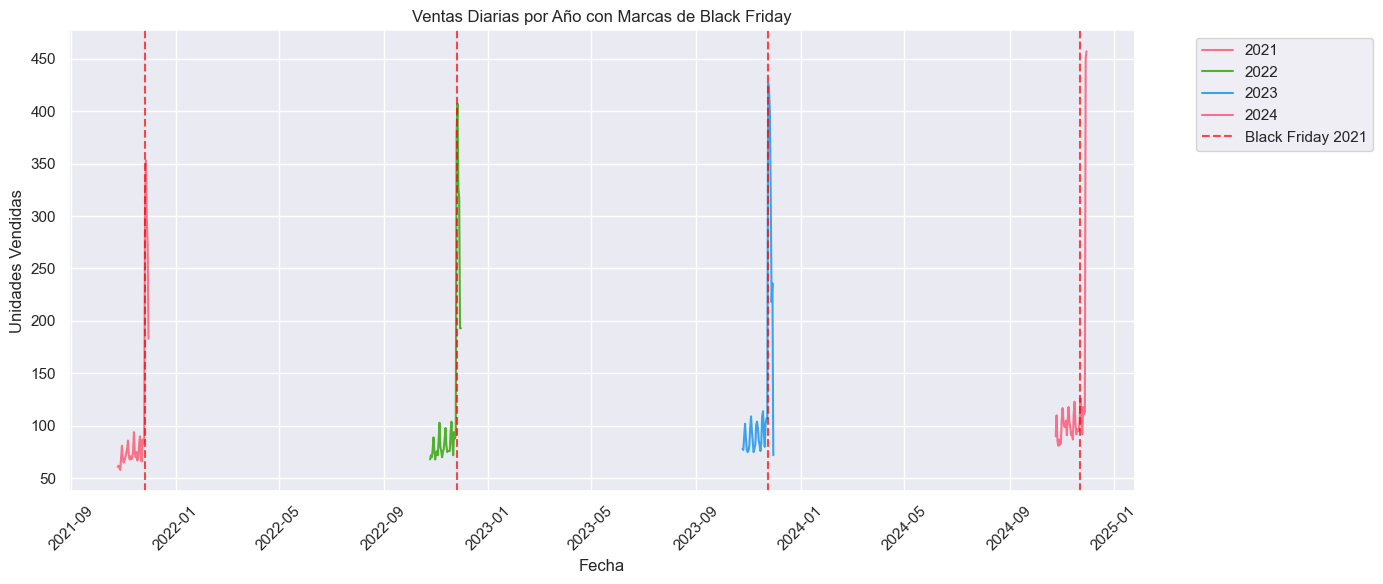

In [67]:
# Series temporales por año
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Crear directorio si no existe
os.makedirs('../docs/graficos', exist_ok=True)

# Configuración general
sns.set_theme(style="darkgrid", palette="husl")

# Agrupar datos por fecha
df_ts = df_merged.groupby('fecha')['unidades_vendidas'].sum().reset_index()
df_ts['año'] = df_ts['fecha'].dt.year

plt.figure(figsize=(14, 6))
sns.lineplot(data=df_ts, x='fecha', y='unidades_vendidas', hue='año', palette='husl')

# Black Friday (4to viernes de noviembre)
years = df_ts['año'].unique()
for y in years:
    nov = pd.date_range(start=f'{y}-11-01', end=f'{y}-11-30')
    fridays = nov[nov.weekday == 4]
    if len(fridays) >= 4:
        bf_date = fridays[3]
        plt.axvline(bf_date, color='red', linestyle='--', alpha=0.7, label=f'Black Friday {y}' if y == years[0] else '_nolegend_')

plt.title('Ventas Diarias por Año con Marcas de Black Friday')
plt.xlabel('Fecha')
plt.ylabel('Unidades Vendidas')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../docs/graficos/01_series_temporales_anio.png')
plt.show()

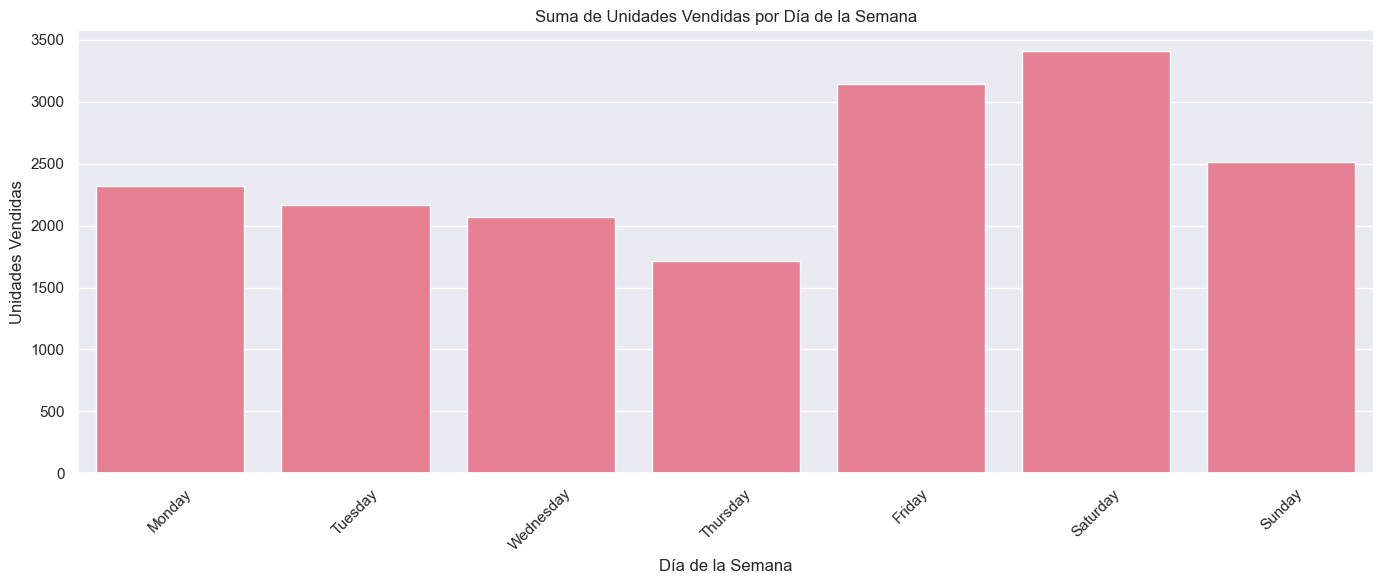

In [68]:
# Ventas por día de la semana
plt.figure(figsize=(14, 6))
sns.set_theme(style="darkgrid", palette="husl")

df_merged['dia_semana'] = df_merged['fecha'].dt.day_name()
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_dia = df_merged.groupby('dia_semana')['unidades_vendidas'].sum().reindex(orden_dias).reset_index()

sns.barplot(data=df_dia, x='dia_semana', y='unidades_vendidas')
plt.title('Suma de Unidades Vendidas por Día de la Semana')
plt.xlabel('Día de la Semana')
plt.ylabel('Unidades Vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../docs/graficos/02_ventas_dia_semana.png')
plt.show()

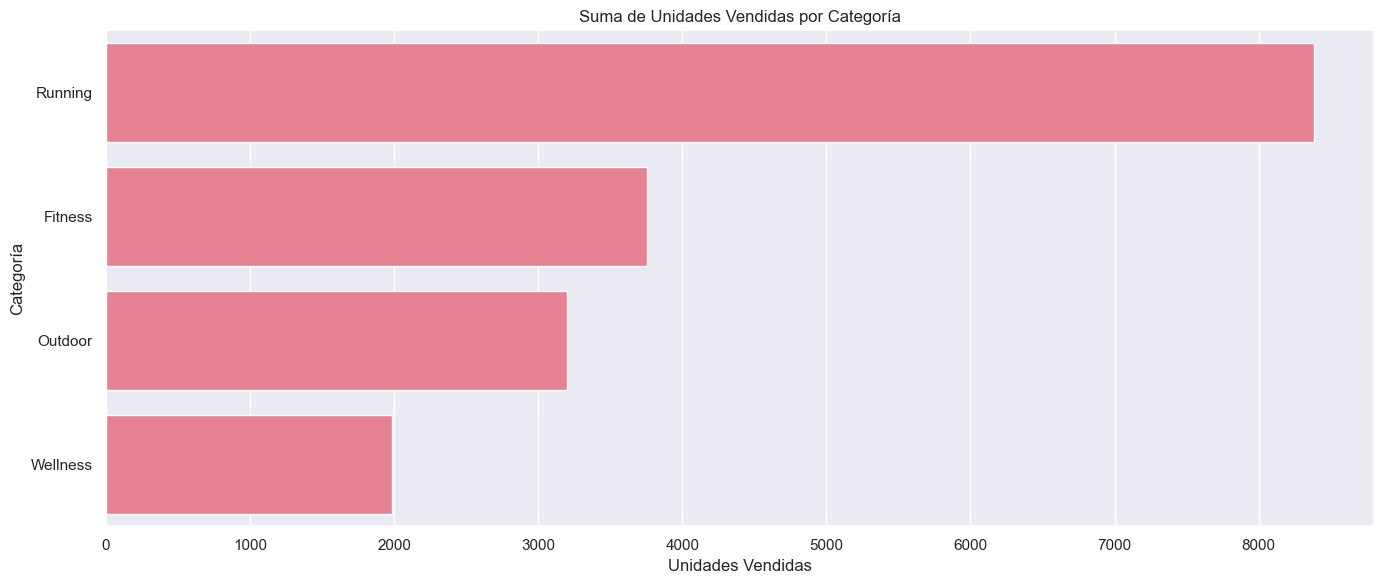

In [69]:
# Ventas por categoría
plt.figure(figsize=(14, 6))
sns.set_theme(style="darkgrid", palette="husl")

df_cat = df_merged.groupby('categoria')['unidades_vendidas'].sum().sort_values(ascending=False).reset_index()

sns.barplot(data=df_cat, y='categoria', x='unidades_vendidas', orient='h')
plt.title('Suma de Unidades Vendidas por Categoría')
plt.xlabel('Unidades Vendidas')
plt.ylabel('Categoría')
plt.tight_layout()
plt.savefig('../docs/graficos/03_ventas_categoria.png')
plt.show()

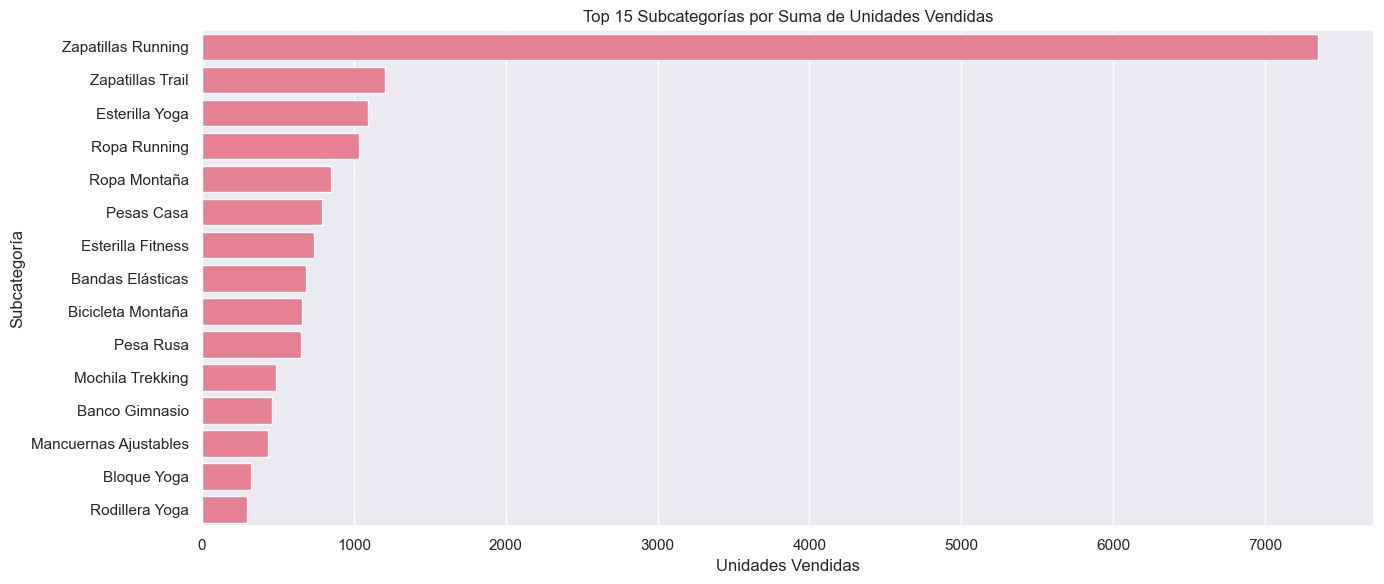

In [70]:
# Ventas por subcategoría (Top 15)
plt.figure(figsize=(14, 6))
sns.set_theme(style="darkgrid", palette="husl")

df_subcat = df_merged.groupby('subcategoria')['unidades_vendidas'].sum().sort_values(ascending=False).head(15).reset_index()

sns.barplot(data=df_subcat, y='subcategoria', x='unidades_vendidas', orient='h')
plt.title('Top 15 Subcategorías por Suma de Unidades Vendidas')
plt.xlabel('Unidades Vendidas')
plt.ylabel('Subcategoría')
plt.tight_layout()
plt.savefig('../docs/graficos/04_ventas_subcategoria.png')
plt.show()

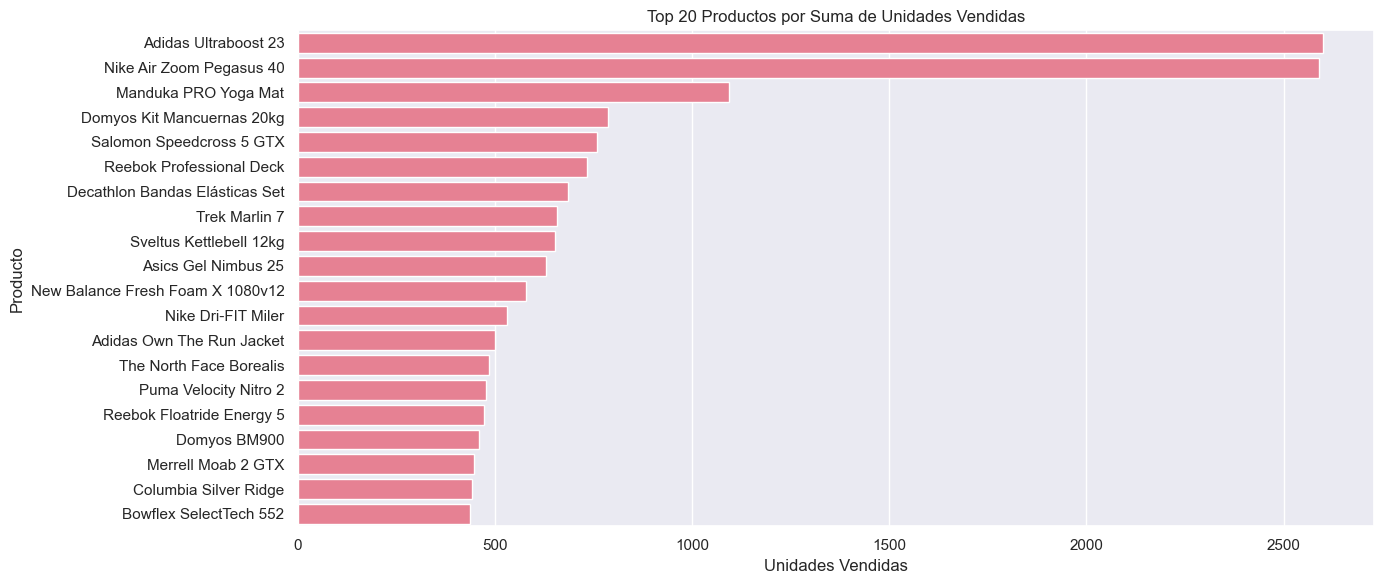

In [71]:
# Top 20 productos
plt.figure(figsize=(14, 6))
sns.set_theme(style="darkgrid", palette="husl")

df_prod = df_merged.groupby('nombre')['unidades_vendidas'].sum().sort_values(ascending=False).head(20).reset_index()

sns.barplot(data=df_prod, y='nombre', x='unidades_vendidas', orient='h')
plt.title('Top 20 Productos por Suma de Unidades Vendidas')
plt.xlabel('Unidades Vendidas')
plt.ylabel('Producto')
plt.tight_layout()
plt.savefig('../docs/graficos/05_top20_productos.png')
plt.show()

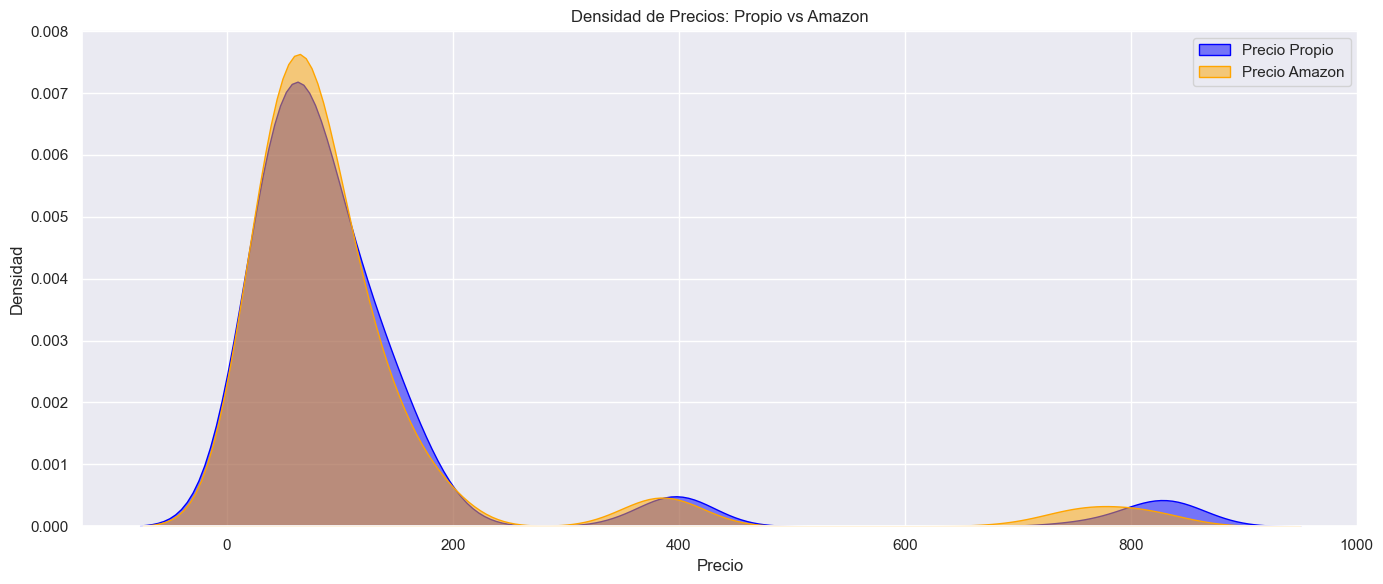

In [72]:
# Densidad de precios (Propios vs Amazon)
plt.figure(figsize=(14, 6))
sns.set_theme(style="darkgrid", palette="husl")

sns.kdeplot(data=df_merged, x='precio_venta', fill=True, label='Precio Propio', color='blue', alpha=0.5)
sns.kdeplot(data=df_merged, x='Amazon', fill=True, label='Precio Amazon', color='orange', alpha=0.5)

plt.title('Densidad de Precios: Propio vs Amazon')
plt.xlabel('Precio')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.savefig('../docs/graficos/06_densidad_precios.png')
plt.show()

## 📅 6.2 Extracción de Variables Temporales


In [73]:
import pandas as pd
import holidays

# --- CONFIGURACIÓN DE VARIABLES TEMPORALES (CORREGIDO) ---

# 1. Instanciar festivos de España
es_holidays = holidays.Spain()

# 2. Identificar fechas dinámicas (Black Friday y Cyber Monday) por año
# Aseguramos que 'fecha' sea datetime
df_merged['fecha'] = pd.to_datetime(df_merged['fecha'])
years = df_merged['fecha'].dt.year.unique()
black_fridays = {}
cyber_mondays = {}

for y in years:
    # El Black Friday es el 4to viernes de noviembre
    nov_dates = pd.date_range(start=f'{y}-11-01', end=f'{y}-11-30')
    fridays = [d for d in nov_dates if d.weekday() == 4]
    if len(fridays) >= 4:
        bf = fridays[3]
        black_fridays[y] = bf
        cyber_mondays[y] = bf + pd.Timedelta(days=3)

# 3. Extracción de componentes básicos
df_merged['año'] = df_merged['fecha'].dt.year
df_merged['mes'] = df_merged['fecha'].dt.month
df_merged['dia_mes'] = df_merged['fecha'].dt.day
df_merged['dia_semana'] = df_merged['fecha'].dt.dayofweek 

# 4. Variables binarias de calendario
df_merged['es_fin_semana'] = df_merged['dia_semana'].isin([5, 6]).astype(int)
df_merged['es_festivo'] = df_merged['fecha'].apply(lambda x: 1 if x in es_holidays else 0)

# 5. Variables de eventos comerciales
df_merged['es_black_friday'] = df_merged.apply(
    lambda row: 1 if row['fecha'] == black_fridays.get(row['año']) else 0, axis=1
)
df_merged['es_cyber_monday'] = df_merged.apply(
    lambda row: 1 if row['fecha'] == cyber_mondays.get(row['año']) else 0, axis=1
)

# 6. Variables adicionales de estacionalidad
df_merged['trimestre'] = df_merged['fecha'].dt.quarter
df_merged['semana_anio'] = df_merged['fecha'].dt.isocalendar().week.astype(int)

# Verificación final
print(f"Variables creadas exitosamente. Dimensiones: {df_merged.shape}")
display(df_merged[['fecha', 'es_festivo', 'es_black_friday', 'es_cyber_monday']].sort_values('fecha', ascending=False).head(5))


Variables creadas exitosamente. Dimensiones: (3552, 23)


,fecha,es_festivo,es_black_friday,es_cyber_monday
3551,2024-11-30,0,0,0
3539,2024-11-30,0,0,0
3528,2024-11-30,0,0,0
3529,2024-11-30,0,0,0
3530,2024-11-30,0,0,0


In [74]:
display(df_merged.head())


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,dia_semana,año,mes,dia_mes,es_fin_semana,es_festivo,es_black_friday,es_cyber_monday,trimestre,semana_anio
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,...,0,2021,10,25,0,0,0,0,4,43
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,...,0,2021,10,25,0,0,0,0,4,43
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,...,0,2021,10,25,0,0,0,0,4,43
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,...,0,2021,10,25,0,0,0,0,4,43
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,...,0,2021,10,25,0,0,0,0,4,43


In [75]:
df_merged.shape

(3552, 23)

## 📈 4.2 Variables de Rezago (Lags) y Medias Móviles


In [76]:
def create_lag_features(df, target_col, max_lag=7):
    """
    Crea variables lag de forma independiente por grupo (producto y año) 
    para evitar contaminación de datos entre periodos anuales.
    """
    df_temp = df.copy()
    # Agrupamos por producto y año para que el shift sea independiente
    group_cols = ['producto_id', df_temp['fecha'].dt.year]
    
    for lag in range(1, max_lag + 1):
        df_temp[f'lag_{lag}'] = df_temp.groupby(group_cols)[target_col].shift(lag)
        
    return df_temp


In [77]:
# --- CELDA 1: Verificación previa ---
# 1. Asegurar orden cronológico por producto y fecha
df_merged = df_merged.sort_values(['producto_id', 'fecha']).reset_index(drop=True)

# 2. Verificar columnas críticas
print(f"Tipo de dato 'fecha': {df_merged['fecha'].dtype}")
print(f"Resumen 'unidades_vendidas':\n{df_merged['unidades_vendidas'].describe()}")

# 3. Mostrar años disponibles
años = df_merged['fecha'].dt.year.unique()
print(f"\nAños detectados: {años}")

# 4. Confirmar orden ascendente
is_sorted = df_merged.groupby('producto_id')['fecha'].apply(lambda x: x.is_monotonic_increasing).all()
print(f"¿Datos ordenados correctamente?: {'SÍ' if is_sorted else 'NO'}")


Tipo de dato 'fecha': datetime64[ns]
Resumen 'unidades_vendidas':
count    3552.00000
mean        4.87866
std         6.31102
min         1.00000
25%         2.00000
50%         3.00000
75%         5.00000
max        85.00000
Name: unidades_vendidas, dtype: float64

Años detectados: [2021 2022 2023 2024]
¿Datos ordenados correctamente?: SÍ


In [78]:
# --- CELDA 2: Creación de lags por año ---
# Aplicamos la función para crear lags del 1 al 7
df_merged = create_lag_features(df_merged, target_col='unidades_vendidas', max_lag=7)

# Visualizar el efecto del shift en el cambio de año (debe haber NaNs)
display(df_merged.filter(like='lag_').head(7))


,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6.0,NaN,NaN,NaN,NaN,NaN,NaN
2,8.0,6.0,NaN,NaN,NaN,NaN,NaN
3,8.0,8.0,6.0,NaN,NaN,NaN,NaN
4,7.0,8.0,8.0,6.0,NaN,NaN,NaN
5,12.0,7.0,8.0,8.0,6.0,NaN,NaN
6,12.0,12.0,7.0,8.0,8.0,6.0,NaN


In [79]:
# --- CELDA 3: Creación de media móvil por año ---
# Calculamos la media móvil de 7 días agrupando por producto y año
# min_periods=7 asegura que no haya cálculos con ventanas incompletas
df_merged['rolling_mean_7'] = (
    df_merged.groupby(['producto_id', df_merged['fecha'].dt.year])['unidades_vendidas']
    .transform(lambda x: x.rolling(window=7, min_periods=7).mean())
)

display(df_merged[['fecha', 'unidades_vendidas', 'rolling_mean_7']].iloc[6:10])


,fecha,unidades_vendidas,rolling_mean_7
6,2021-10-31,9,8.857143
7,2021-11-01,7,9.000000
8,2021-11-02,10,9.285714
9,2021-11-03,11,9.714286


In [80]:
# --- CELDA 4: Eliminación de nulos ---
cols_lag = [f'lag_{i}' for i in range(1, 8)]
cols_check = cols_lag + ['rolling_mean_7']

# 1. Diagnóstico de nulos
nulos_totales = df_merged[cols_check].isnull().any(axis=1).sum()
print(f"Registros con nulos encontrados: {nulos_totales}")

# Mostrar ejemplo de NaNs (típicamente los primeros 6-7 días de cada año por producto)
display(df_merged[df_merged[cols_check].isnull().any(axis=1)].head(3))

# 2. Limpieza total
df_merged_clean = df_merged.dropna(subset=cols_check).copy()

# 3. Verificación
print(f"Nulos restantes en el dataset limpio: {df_merged_clean[cols_check].isnull().sum().sum()}")


Registros con nulos encontrados: 672


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,trimestre,semana_anio,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,rolling_mean_7
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,...,4,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-10-26,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,8,117.37,938.96,...,4,43,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-10-27,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,8,114.27,914.16,...,4,43,8.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN


Nulos restantes en el dataset limpio: 0


In [81]:
# --- CELDA 5: Validación ---
print(f"Shape antes de limpiar: {df_merged.shape}")
print(f"Shape después de limpiar: {df_merged_clean.shape}")

# Verificar independencia: El primer registro de cada año debe tener historia completa
print("\nVerificación de los primeros registros de cada año (Muestra):")
display(df_merged_clean.groupby(df_merged_clean['fecha'].dt.year).head(3))

# Estadísticas descriptivas
print("\nDistribución de las nuevas variables:")
display(df_merged_clean[cols_check].describe().T)


Shape antes de limpiar: (3552, 31)
Shape después de limpiar: (2880, 31)

Verificación de los primeros registros de cada año (Muestra):


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,trimestre,semana_anio,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,rolling_mean_7
7,2021-11-01,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,7,115.07,805.49,...,4,44,9.0,12.0,12.0,7.0,8.0,8.0,6.0,9.000000
8,2021-11-02,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,10,116.10,1161.00,...,4,44,7.0,9.0,12.0,12.0,7.0,8.0,8.0,9.285714
9,2021-11-03,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,11,114.58,1260.38,...,4,44,10.0,7.0,9.0,12.0,12.0,7.0,8.0,9.714286
44,2022-11-01,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,10,112.83,1128.30,...,4,44,9.0,14.0,14.0,12.0,12.0,11.0,10.0,11.714286
45,2022-11-02,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,15,112.95,1694.25,...,4,44,10.0,9.0,14.0,14.0,12.0,12.0,11.0,12.285714
46,2022-11-03,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,9,114.98,1034.82,...,4,44,15.0,10.0,9.0,14.0,14.0,12.0,12.0,11.857143
81,2023-11-01,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,9,117.32,1055.88,...,4,44,11.0,15.0,15.0,14.0,14.0,10.0,11.0,12.571429
82,2023-11-02,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,11,111.99,1231.89,...,4,44,9.0,11.0,15.0,15.0,14.0,14.0,10.0,12.714286
83,2023-11-03,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,14,114.91,1608.74,...,4,44,11.0,9.0,11.0,15.0,15.0,14.0,14.0,12.714286
118,2024-11-01,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,15,118.32,1774.80,...,4,44,16.0,14.0,14.0,15.0,13.0,20.0,16.0,15.285714



Distribución de las nuevas variables:


,count,mean,std,min,25%,50%,75%,max
lag_1,2880.0,5.045486,6.454937,1.0,2.000000,3.0,5.000000,85.000000
lag_2,2880.0,4.755556,6.000576,1.0,2.000000,3.0,4.000000,85.000000
lag_3,2880.0,4.543403,5.710042,1.0,2.000000,3.0,4.000000,85.000000
lag_4,2880.0,4.268056,5.232857,1.0,2.000000,3.0,4.000000,85.000000
lag_5,2880.0,3.942361,4.407296,1.0,2.000000,3.0,4.000000,85.000000
lag_6,2880.0,3.714236,3.674202,1.0,2.000000,3.0,4.000000,85.000000
lag_7,2880.0,3.571528,3.130665,1.0,2.000000,3.0,4.000000,22.000000
rolling_mean_7,2880.0,4.503770,4.712218,1.0,2.285714,3.0,4.428571,53.285714


In [82]:
# --- CELDA 6: Exportar ---
import os

# Crear carpeta processed si no existe
os.makedirs('../data/processed', exist_ok=True)

# Guardar
output_path = '../data/processed/ventas_features.csv'
df_merged_clean.to_csv(output_path, index=False)

print(f"✅ Dataset exportado a: {output_path}")
print(f"Rango temporal final: {df_merged_clean['fecha'].min().date()} a {df_merged_clean['fecha'].max().date()}")
print(f"Columnas totales: {len(df_merged_clean.columns)}")


✅ Dataset exportado a: ../data/processed/ventas_features.csv
Rango temporal final: 2021-11-01 a 2024-11-30
Columnas totales: 31


In [83]:
# Contar el número de registros por cada año
registros_por_año = df_merged_clean.groupby('año').size()

print("Cantidad de registros por año:")
print(registros_por_año)


Cantidad de registros por año:
año
2021    720
2022    720
2023    720
2024    720
dtype: int64


In [84]:
# Calcular el porcentaje de descuento/variación de precio
df_merged_clean['descuento_porcentaje'] = ((df_merged_clean['precio_venta'] - df_merged_clean['precio_base']) / df_merged_clean['precio_base']) * 100

# Redondeamos a 2 decimales para que sea más legible
df_merged_clean['descuento_porcentaje'] = df_merged_clean['descuento_porcentaje'].round(2)

# Mostrar los resultados para verificar
display(df_merged_clean[['nombre', 'precio_base', 'precio_venta', 'descuento_porcentaje']].head())


,nombre,precio_base,precio_venta,descuento_porcentaje
7,Nike Air Zoom Pegasus 40,115,115.07,0.06
8,Nike Air Zoom Pegasus 40,115,116.10,0.96
9,Nike Air Zoom Pegasus 40,115,114.58,-0.37
10,Nike Air Zoom Pegasus 40,115,112.23,-2.41
11,Nike Air Zoom Pegasus 40,115,113.81,-1.03


## 💵 6.3 Análisis de Precios y Competencia


In [85]:
# Lista de columnas de competidores
competidores = ['Amazon', 'Decathlon', 'Deporvillage']

# 1. Crear el precio promedio de la competencia
# axis=1 calcula el promedio por fila
df_merged_clean['precio_competencia'] = df_merged_clean[competidores].mean(axis=1)

# 2. Crear el ratio de precios (Nuestro Precio / Promedio Competencia)
# Un ratio < 1 significa que somos más baratos que el promedio de la competencia
df_merged_clean['ratio_precio'] = df_merged_clean['precio_venta'] / df_merged_clean['precio_competencia']

# 3. Eliminar las columnas originales de los competidores
df_merged_clean = df_merged_clean.drop(columns=competidores)

# Redondear para mantener el DataFrame limpio
df_merged_clean['precio_competencia'] = df_merged_clean['precio_competencia'].round(2)
df_merged_clean['ratio_precio'] = df_merged_clean['ratio_precio'].round(4)

# Mostrar resultados
print(f"Columnas actuales en el DataFrame: {df_merged_clean.columns.tolist()}")
display(df_merged_clean[['nombre', 'precio_venta', 'precio_competencia', 'ratio_precio']].head())


Columnas actuales en el DataFrame: ['fecha', 'producto_id', 'nombre', 'categoria', 'subcategoria', 'precio_base', 'es_estrella', 'unidades_vendidas', 'precio_venta', 'ingresos', 'dia_semana', 'año', 'mes', 'dia_mes', 'es_fin_semana', 'es_festivo', 'es_black_friday', 'es_cyber_monday', 'trimestre', 'semana_anio', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'rolling_mean_7', 'descuento_porcentaje', 'precio_competencia', 'ratio_precio']


,nombre,precio_venta,precio_competencia,ratio_precio
7,Nike Air Zoom Pegasus 40,115.07,95.35,1.2068
8,Nike Air Zoom Pegasus 40,116.10,96.15,1.2074
9,Nike Air Zoom Pegasus 40,114.58,95.24,1.2031
10,Nike Air Zoom Pegasus 40,112.23,96.59,1.1619
11,Nike Air Zoom Pegasus 40,113.81,96.17,1.1834


# 🏷️ 7. CODIFICACIÓN CATEGÓRICA (OHE)


In [90]:
# 1. Eliminar columnas OHE de ejecuciones previas para evitar duplicados
cols_a_eliminar = df_merged_clean.filter(like='_h_').columns
df_merged_clean = df_merged_clean.drop(columns=cols_a_eliminar)

# 2. Crear copias de las variables originales con el sufijo _h
df_merged_clean['nombre_h'] = df_merged_clean['nombre']
df_merged_clean['categoria_h'] = df_merged_clean['categoria']
df_merged_clean['subcategoria_h'] = df_merged_clean['subcategoria']

# 3. Aplicar One-Hot Encoding sobre las nuevas variables
# pd.get_dummies transformará cada valor único en una nueva columna de 0s y 1s
columnas_ohe = ['nombre_h', 'categoria_h', 'subcategoria_h']
df_merged_clean = pd.get_dummies(df_merged_clean, columns=columnas_ohe)

# Verificamos que el total de columnas sea 75 (o el esperado para una sola ejecución)
print(f"Número total de columnas tras OHE: {len(df_merged_clean.columns)}")
display(df_merged_clean.filter(like='_h_').head())


Número total de columnas tras OHE: 75


,nombre_h_Adidas Own The Run Jacket,nombre_h_Adidas Ultraboost 23,nombre_h_Asics Gel Nimbus 25,nombre_h_Bowflex SelectTech 552,nombre_h_Columbia Silver Ridge,nombre_h_Decathlon Bandas Elásticas Set,nombre_h_Domyos BM900,nombre_h_Domyos Kit Mancuernas 20kg,nombre_h_Gaiam Premium Yoga Block,nombre_h_Liforme Yoga Pad,...,subcategoria_h_Esterilla Yoga,subcategoria_h_Mancuernas Ajustables,subcategoria_h_Mochila Trekking,subcategoria_h_Pesa Rusa,subcategoria_h_Pesas Casa,subcategoria_h_Rodillera Yoga,subcategoria_h_Ropa Montaña,subcategoria_h_Ropa Running,subcategoria_h_Zapatillas Running,subcategoria_h_Zapatillas Trail
7,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
8,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
9,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
10,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
11,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


In [96]:
# Guardar el DataFrame final
df_merged_clean.to_csv('../data/processed/df.csv', index=False)

print("✅ ¡Listo! Archivo guardado en data/processed/df.csv")


✅ ¡Listo! Archivo guardado en data/processed/df.csv


# ✂️ 9. DIVISIÓN DEL DATASET (TRAIN / VALIDATION)


In [99]:
# --- CELDA 7: División del Dataset (Train/Validation) ---
# Según la instrucción: train (2021-2023) y validation (2024)

# 1. Crear conjunto de entrenamiento (2021, 2022, 2023)
train_df = df[df['año'] < 2024].copy()

# 2. Crear conjunto de validación (2024)
validation_df = df[df['año'] == 2024].copy()

# 3. Mostrar resultados
print("Resultados de la división:")
print(f"Registros en train_df (2021-2023): {len(train_df)}")
print(f"Registros en validation_df (2024): {len(validation_df)}")
print(f"Total registros: {len(df)}")

# Verificar que no se perdió ningún registro
if len(train_df) + len(validation_df) == len(df):
    print("\n✅ División completada sin pérdida de datos.")
else:
    print("\n⚠️ Advertencia: La suma de registros no coincide con el total.")

Resultados de la división:
Registros en train_df (2021-2023): 2160
Registros en validation_df (2024): 720
Total registros: 2880

✅ División completada sin pérdida de datos.


# 🤖 10. ENTRENAMIENTO DEL MODELO Y MÉTRICAS


In [100]:
# --- CELDA 8: Entrenamiento del Modelo de Forecasting ---
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np
import pandas as pd

# 1. Selección de Variables (Features vs Target)
target = 'unidades_vendidas'
cols_excluir = ['fecha', 'ingresos', target]

# Identificar columnas tipo object para excluirlas
cols_object = train_df.select_dtypes(include=['object']).columns.tolist()
features = [c for c in train_df.columns if c not in cols_excluir and c not in cols_object]

X_train, y_train = train_df[features], train_df[target]
X_val, y_val = validation_df[features], validation_df[target]

print(f"Variables predictoras seleccionadas: {len(features)}")
print(f"Ejemplos de features: {features[:5]}... {features[-5:]}")

# 2. Entrenamiento del Modelo (HistGradientBoostingRegressor)
# Parámetros conservadores para evitar overfitting
model = HistGradientBoostingRegressor(
    learning_rate=0.01,      # Bajo para aprendizaje pausado
    max_iter=1000,           # Muchos árboles
    max_depth=6,             # Profundidad moderada
    l2_regularization=0.5,   # Regularización L2 fuerte
    random_state=42
)

model.fit(X_train, y_train)

# 3. Predicciones
y_pred = model.predict(X_val)

# 4. Baseline Naive (Media histórica)
y_val_naive = np.full_like(y_val, y_train.mean())

# 5. Evaluación de Métricas
def calcular_metricas(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE': mean_absolute_percentage_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }

metrics_model = calcular_metricas(y_val, y_pred)
metrics_naive = calcular_metricas(y_val, y_val_naive)

# 6. Comparativa
comparativa = pd.DataFrame({
    'HistGradientBoosting': metrics_model,
    'Baseline (Media)': metrics_naive
}).T

print("\n--- Comparativa de Rendimiento (Validación 2024) ---")
display(comparativa.round(4))

Variables predictoras seleccionadas: 68
Ejemplos de features: ['precio_base', 'es_estrella', 'precio_venta', 'dia_semana', 'año']... ['subcategoria_h_Rodillera Yoga', 'subcategoria_h_Ropa Montaña', 'subcategoria_h_Ropa Running', 'subcategoria_h_Zapatillas Running', 'subcategoria_h_Zapatillas Trail']

--- Comparativa de Rendimiento (Validación 2024) ---


,MAE,RMSE,MAPE,R2
HistGradientBoosting,1.0120,2.0249,0.2017,0.9084
Baseline (Media),3.5222,6.6987,0.8589,-0.0020


# 📈 11. EVALUACIÓN DETALLADA Y VISUALIZACIÓN


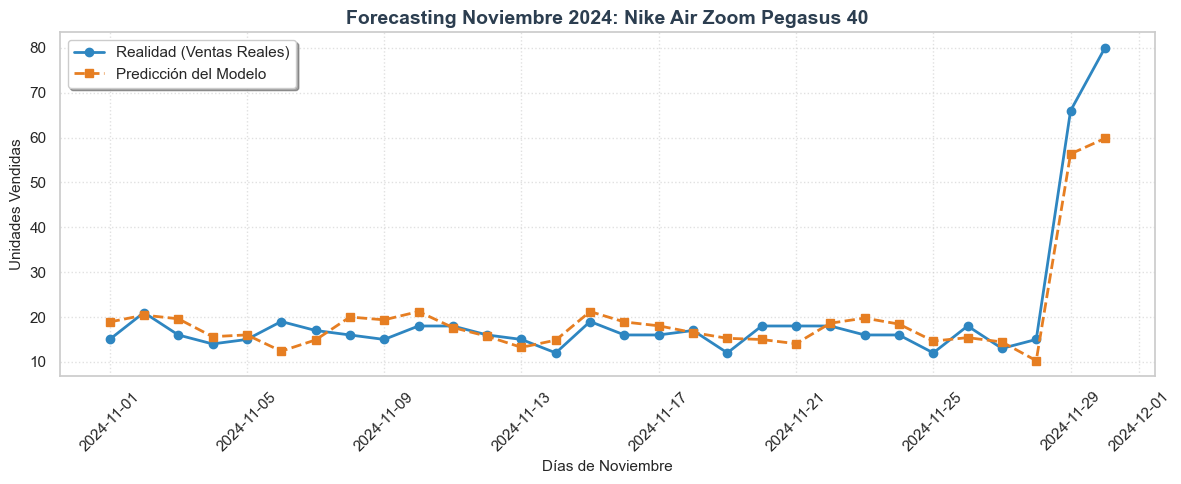

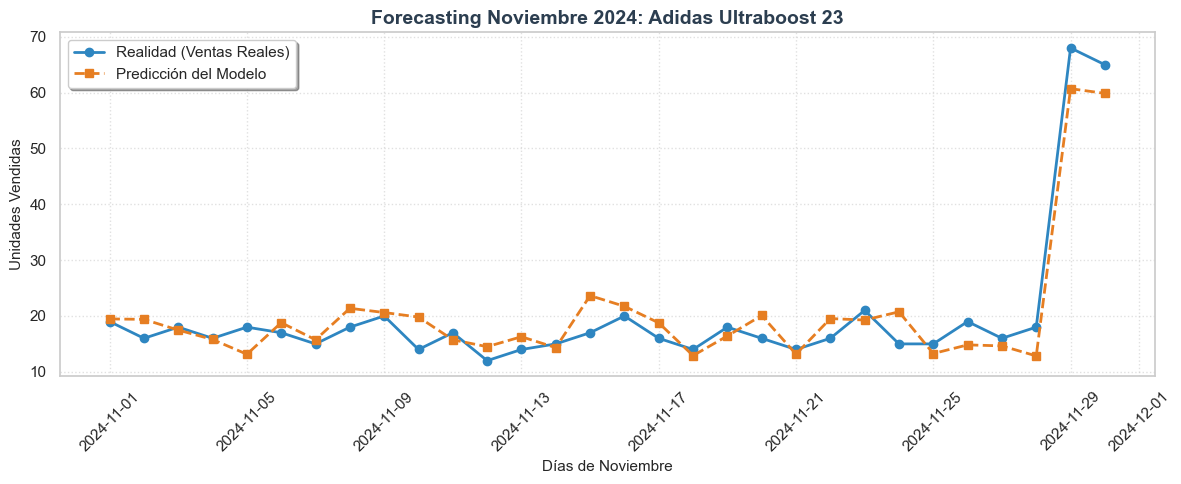

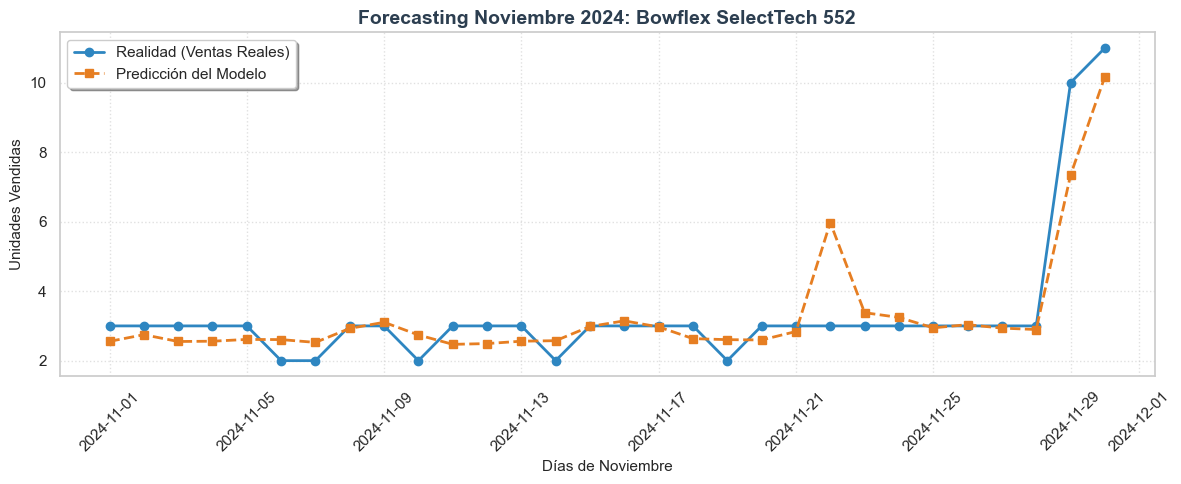

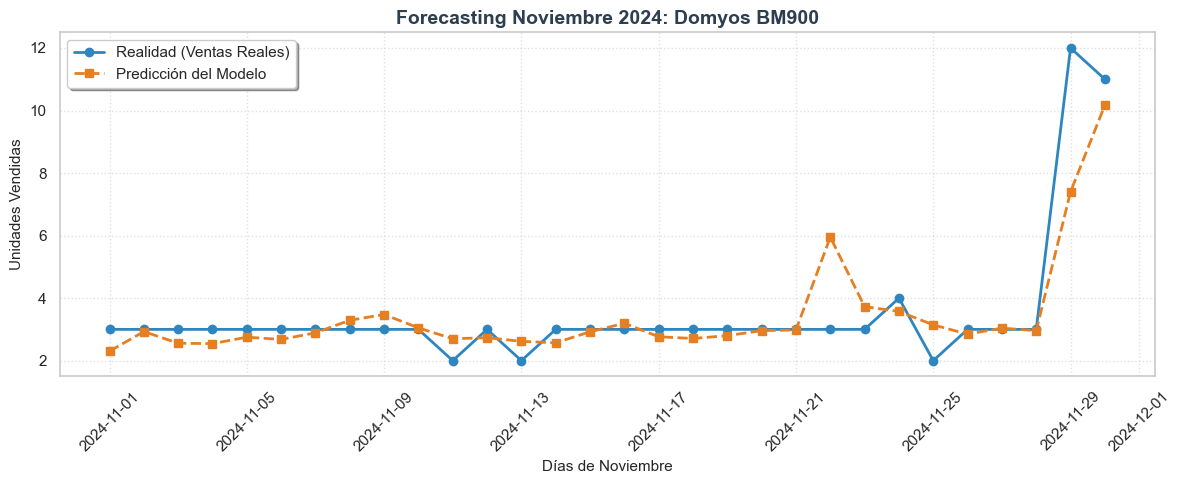

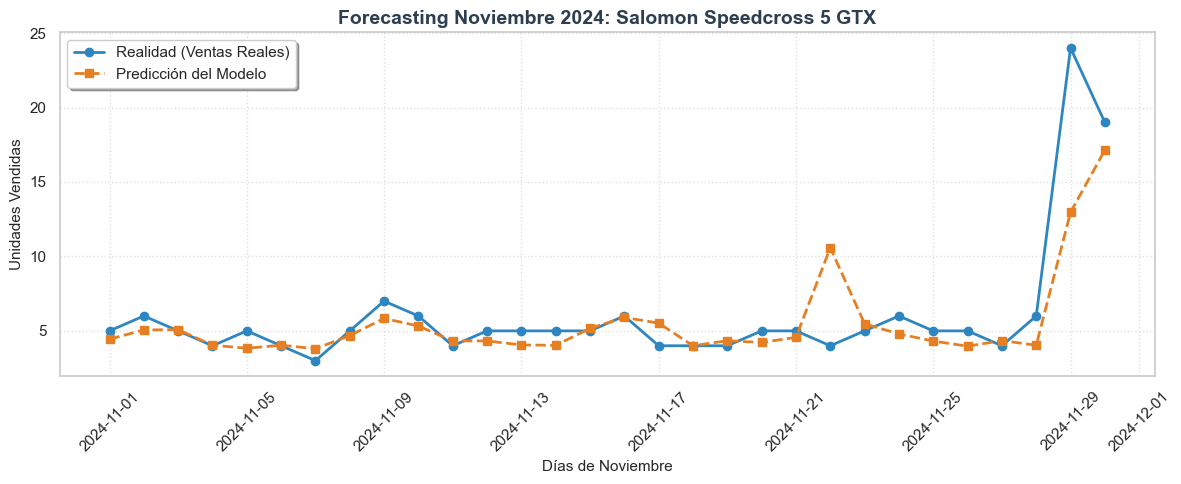

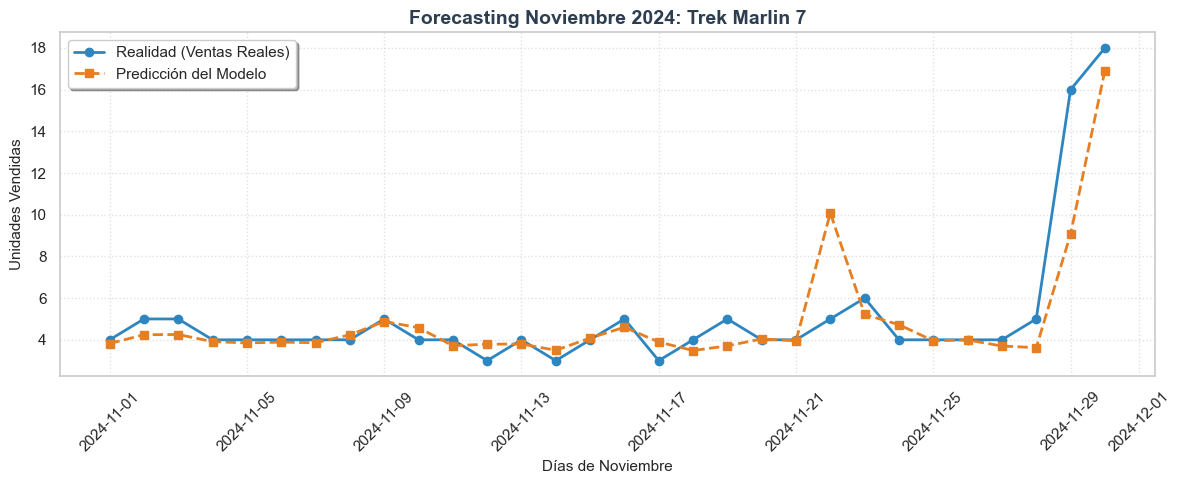

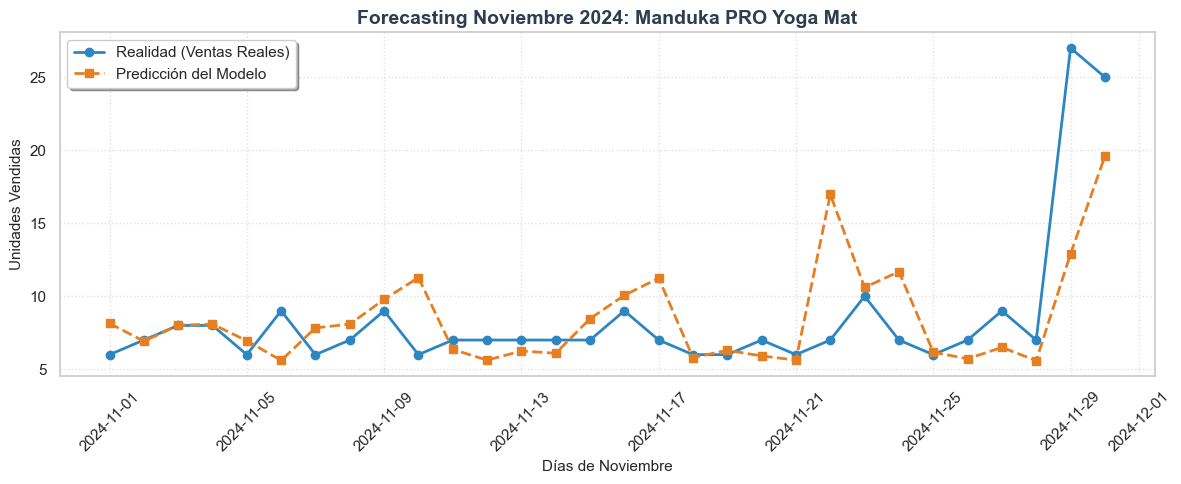

In [101]:
# --- CELDA 9: Predicciones de Noviembre 2024 (Productos Estrella) ---
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtrar datos de Noviembre 2024
df_nov = validation_df[validation_df['mes'] == 11].copy()

# 2. Generar predicciones para Noviembre
# Usamos las mismas features definidas en la celda anterior
df_nov['prediccion'] = model.predict(df_nov[features])

# 3. Filtrar los 7 productos estrella
df_stars = df_nov[df_nov['es_estrella'] == True].copy()
productos_estrella = df_stars['nombre'].unique()

# 4. Configuración estética y generación de 7 gráficos individuales
sns.set_style("whitegrid")

for producto in productos_estrella:
    # Filtrar y ordenar por fecha para el gráfico de líneas
    data_plot = df_stars[df_stars['nombre'] == producto].sort_values('fecha')
    
    plt.figure(figsize=(12, 5))
    
    # Dibujar líneas de realidad y predicción
    plt.plot(data_plot['fecha'], data_plot['unidades_vendidas'], 
             marker='o', label='Realidad (Ventas Reales)', color='#2E86C1', linewidth=2)
    plt.plot(data_plot['fecha'], data_plot['prediccion'], 
             marker='s', label='Predicción del Modelo', color='#E67E22', linestyle='--', linewidth=2)
    
    # Personalización del gráfico
    plt.title(f"Forecasting Noviembre 2024: {producto}", fontsize=14, fontweight='bold', color='#2C3E50')
    plt.xlabel("Días de Noviembre", fontsize=11)
    plt.ylabel("Unidades Vendidas", fontsize=11)
    plt.legend(frameon=True, shadow=True)
    plt.xticks(rotation=45)
    
    # Añadir cuadrícula sutil
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

In [102]:
# --- CELDA 10: Análisis de Error (MAE) por Producto Estrella ---
from sklearn.metrics import mean_absolute_error

# 1. Generar predicciones para TODO el conjunto de validación (2024)
validation_df['prediccion'] = model.predict(validation_df[features])

# 2. Filtrar solo los productos estrella en el conjunto de validación
df_stars_val = validation_df[validation_df['es_estrella'] == True].copy()

# 3. Calcular el MAE por producto mediante una iteración limpia
mae_por_producto = []

for producto in df_stars_val['nombre'].unique():
    subset = df_stars_val[df_stars_val['nombre'] == producto]
    mae = mean_absolute_error(subset['unidades_vendidas'], subset['prediccion'])
    ventas_promedio = subset['unidades_vendidas'].mean()
    
    mae_por_producto.append({
        'Producto': producto,
        'MAE (Error)': mae,
        'Ventas Promedio': ventas_promedio,
        'Error Relativo (%)': (mae / ventas_promedio) * 100
    })

# 4. Convertir a DataFrame, ordenar por precisión y mostrar
df_mae = pd.DataFrame(mae_por_producto).sort_values('MAE (Error)')

print("Desglose de precisión (MAE) por Producto Estrella (Validación 2024):")
display(df_mae.round(2))

Desglose de precisión (MAE) por Producto Estrella (Validación 2024):


,Producto,MAE (Error),Ventas Promedio,Error Relativo (%)
2,Bowflex SelectTech 552,0.51,3.33,15.15
3,Domyos BM900,0.57,3.50,16.33
5,Trek Marlin 7,0.82,5.07,16.12
4,Salomon Speedcross 5 GTX,1.24,6.00,20.67
6,Manduka PRO Yoga Mat,2.27,8.43,26.96
1,Adidas Ultraboost 23,2.77,19.90,13.92
0,Nike Air Zoom Pegasus 40,3.40,19.90,17.11


# 📉 12. ANÁLISIS DE DEGRADACIÓN DEL ERROR


Evolución del Error (MAE) por periodos de 10 días:


Periodo,Días 01-10,Días 11-20,Días 21-30
Producto,,,
Adidas Ultraboost 23,2.18,2.46,3.67
Bowflex SelectTech 552,0.40,0.36,0.75
Domyos BM900,0.32,0.31,1.09
Manduka PRO Yoga Mat,1.57,1.20,4.05
Nike Air Zoom Pegasus 40,3.10,1.91,5.20
Salomon Speedcross 5 GTX,0.58,0.58,2.56
Trek Marlin 7,0.31,0.50,1.64


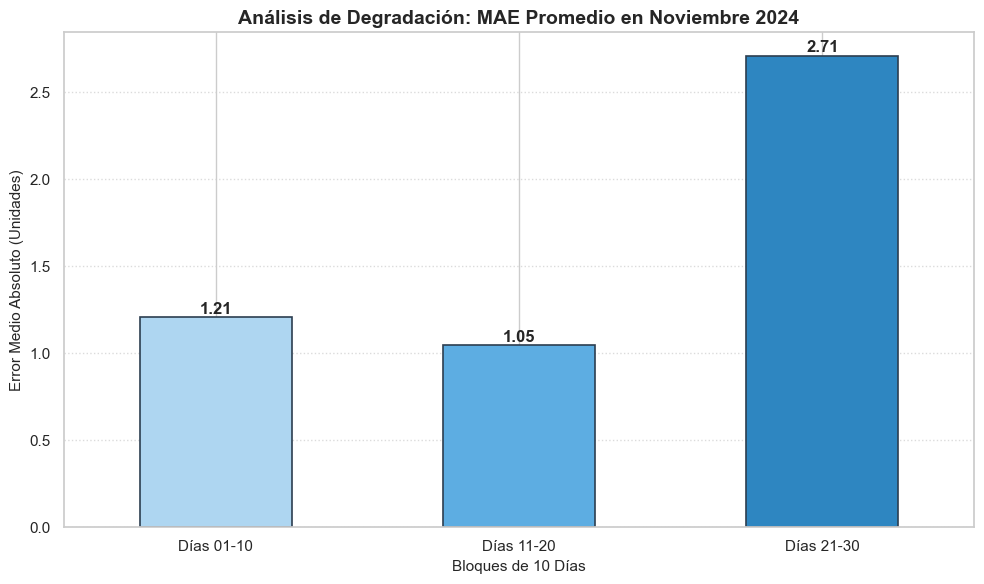

In [103]:
# --- CELDA 11: Análisis de Degradación del Error (Noviembre 2024) ---
# Dividimos el mes en 3 bloques de 10 días para evaluar la estabilidad del modelo

# 1. Definir los periodos decenales
df_nov['periodo'] = pd.cut(
    df_nov['fecha'].dt.day, 
    bins=[0, 10, 20, 31], 
    labels=['Días 01-10', 'Días 11-20', 'Días 21-30']
)

# 2. Calcular MAE por Producto y Periodo para los productos estrella
analisis_degradacion = []

for (producto, periodo), group in df_nov[df_nov['es_estrella']].groupby(['nombre', 'periodo'], observed=False):
    mae = mean_absolute_error(group['unidades_vendidas'], group['prediccion'])
    analisis_degradacion.append({
        'Producto': producto,
        'Periodo': periodo,
        'MAE': mae
    })

# 3. Crear tabla pivote para visualizar la evolución del error
df_degradacion = pd.DataFrame(analisis_degradacion).pivot(index='Producto', columns='Periodo', values='MAE')

print("Evolución del Error (MAE) por periodos de 10 días:")
display(df_degradacion.round(2))

# 4. Visualización Global de Degradación
plt.figure(figsize=(10, 6))
colores = ['#AED6F1', '#5DADE2', '#2E86C1']
df_degradacion.mean().plot(kind='bar', color=colores, edgecolor='#2C3E50', linewidth=1.2)

plt.title("Análisis de Degradación: MAE Promedio en Noviembre 2024", fontsize=14, fontweight='bold')
plt.ylabel("Error Medio Absoluto (Unidades)", fontsize=11)
plt.xlabel("Bloques de 10 Días", fontsize=11)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle=':', alpha=0.7)

# Añadir etiquetas de valor sobre las barras
for i, v in enumerate(df_degradacion.mean()):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 🎯 13. ANÁLISIS ESPECÍFICO: BLACK FRIDAY


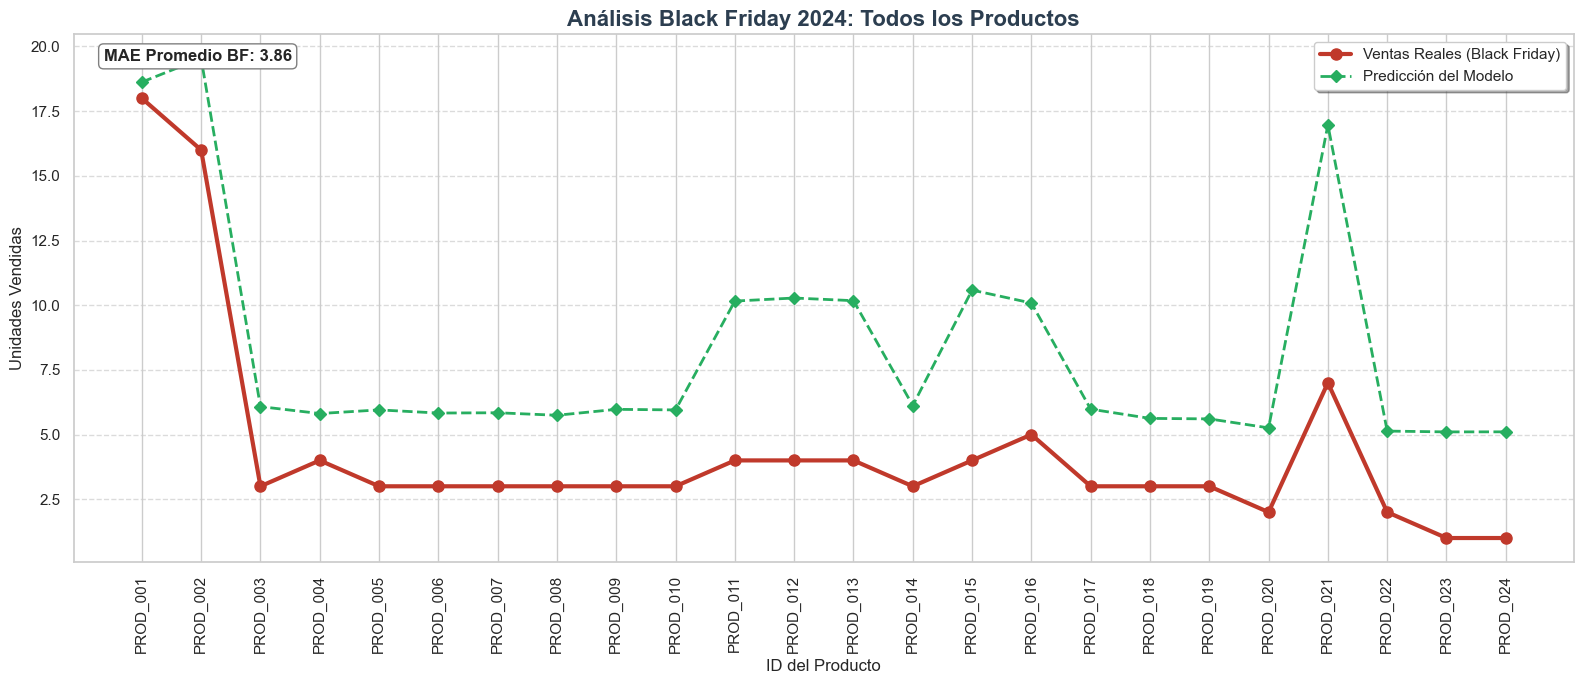

In [104]:
# --- CELDA 12: Análisis Específico Black Friday 2024 ---
# Analizamos el rendimiento del modelo en el día de mayor estrés del sistema

# 1. Filtrar el día de Black Friday 2024
# El flag 'es_black_friday' identifica este evento único en el calendario
df_bf = validation_df[validation_df['es_black_friday'] == True].copy()

# 2. Generar predicciones específicas para este día
df_bf['prediccion'] = model.predict(df_bf[features])

# 3. Ordenar por producto_id para que el gráfico sea legible
df_bf = df_bf.sort_values('producto_id')

# 4. Visualización de alto impacto: Realidad vs Predicción
plt.figure(figsize=(16, 7))

# Líneas de comparación
plt.plot(df_bf['producto_id'], df_bf['unidades_vendidas'], 
         marker='o', label='Ventas Reales (Black Friday)', color='#C0392B', linewidth=3, markersize=8)
plt.plot(df_bf['producto_id'], df_bf['prediccion'], 
         marker='D', label='Predicción del Modelo', color='#27AE60', linestyle='--', linewidth=2, markersize=6)

# Personalización estética
plt.title("Análisis Black Friday 2024: Todos los Productos", fontsize=16, fontweight='bold', color='#2C3E50')
plt.xlabel("ID del Producto", fontsize=12)
plt.ylabel("Unidades Vendidas", fontsize=12)
plt.xticks(rotation=90)
plt.legend(frameon=True, shadow=True, fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Anotación de Error Medio en el gráfico
mae_bf = mean_absolute_error(df_bf['unidades_vendidas'], df_bf['prediccion'])
plt.annotate(f'MAE Promedio BF: {mae_bf:.2f}', xy=(0.02, 0.95), xycoords='axes fraction', 
             fontsize=12, fontweight='bold', bbox=dict(boxstyle="round", fc="white", ec="gray"))

plt.tight_layout()
plt.show()

# 🤖 10. ENTRENAMIENTO DEL MODELO Y MÉTRICAS


In [105]:
# --- CELDA 13: Reentrenamiento del Modelo Final (Dataset Completo 2021-2024) ---
# Una vez validado el rendimiento, reentrenamos con el 100% de los datos para producción

# 1. Preparar datos completos (X, y)
X_final = df[features]
y_final = df[target]

print(f"Iniciando entrenamiento final con {len(X_final)} registros y {len(features)} variables predictoras...")

# 2. Inicializar el regresor con los parámetros óptimos validados anteriormente
model_final = HistGradientBoostingRegressor(
    learning_rate=0.01,      # Convergencia estable
    max_iter=1000,           # Suficiente capacidad de aprendizaje
    max_depth=6,             # Complejidad controlada
    l2_regularization=0.5,   # Regularización para evitar sobreajuste
    random_state=42
)

# 3. Ajuste sobre el histórico completo (2021-2024)
model_final.fit(X_final, y_final)

print("✅ ¡Listo! El modelo 'model_final' ha sido entrenado con el histórico completo de 4 años.")
print(f"Rango de datos utilizado: {df['fecha'].min()} hasta {df['fecha'].max()}")

Iniciando entrenamiento final con 2880 registros y 68 variables predictoras...
✅ ¡Listo! El modelo 'model_final' ha sido entrenado con el histórico completo de 4 años.
Rango de datos utilizado: 2021-11-01 00:00:00 hasta 2024-11-30 00:00:00


# 🗝️ 15. IMPORTANCIA DE VARIABLES Y EXPORTACIÓN


Calculando Permutation Importance (proceso intensivo)...


C:\Users\Danny\AppData\Local\Temp\ipykernel_9264\2045070047.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


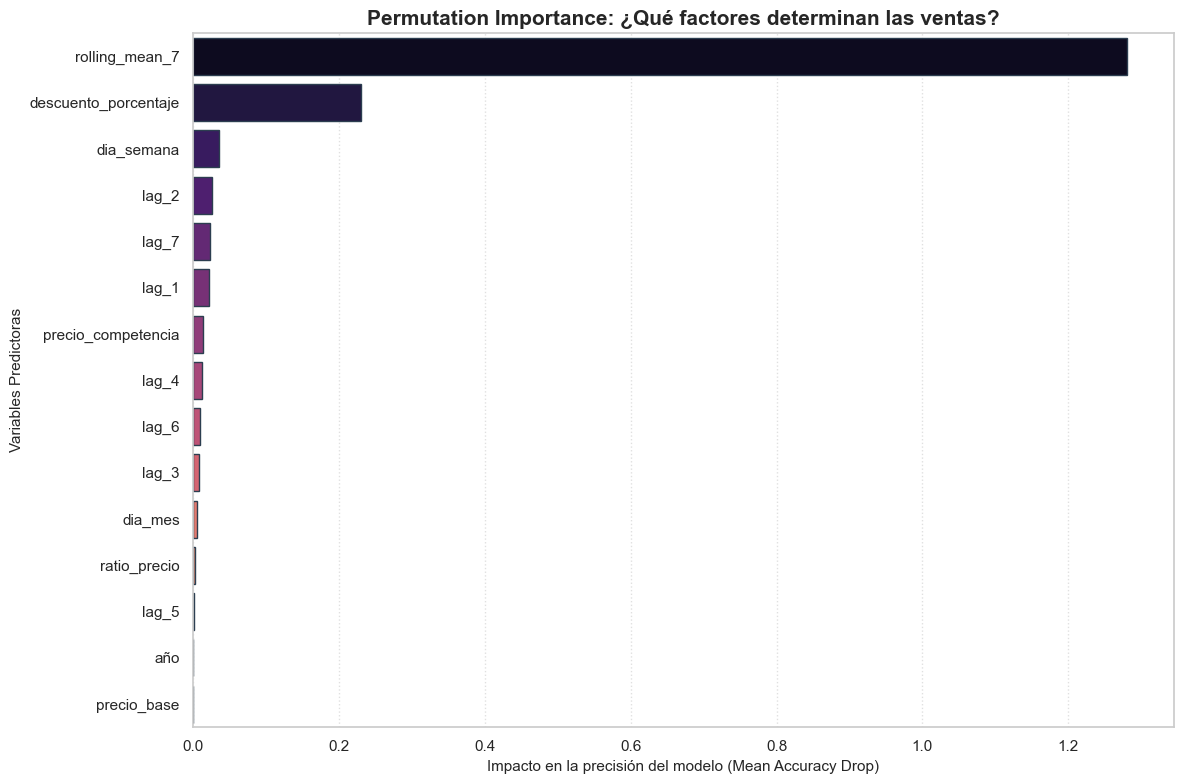

✅ ¡Éxito! El modelo final ha sido exportado a: ../models/modelo_final.joblib
Dimensiones del modelo guardado: 1847.40 KB


In [106]:
# --- CELDA 14: Importancia de Variables y Exportación del Modelo ---
from sklearn.inspection import permutation_importance
import joblib
import os

# 1. Calcular Permutation Importance
# Esta técnica mide cuánto cae el rendimiento del modelo si desordenamos aleatoriamente una variable
print("Calculando Permutation Importance (proceso intensivo)...")
result = permutation_importance(
    model_final, X_final, y_final, 
    n_repeats=5,            # Número de permutaciones por variable
    random_state=42,
    n_jobs=-1               # Usar todos los núcleos disponibles
)

# 2. Organizar resultados en un DataFrame ordenado
importancia_df = pd.DataFrame({
    'Variable': features,
    'Importancia': result.importances_mean
}).sort_values('Importancia', ascending=False)

# 3. Visualización: Top 15 Variables más influyentes
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importancia', 
    y='Variable', 
    data=importancia_df.head(15), 
    palette='magma', 
    edgecolor='#2C3E50'
)

plt.title("Permutation Importance: ¿Qué factores determinan las ventas?", fontsize=15, fontweight='bold')
plt.xlabel("Impacto en la precisión del modelo (Mean Accuracy Drop)", fontsize=11)
plt.ylabel("Variables Predictoras", fontsize=11)
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# 4. Guardar el Modelo Final en formato Joblib
os.makedirs('../models', exist_ok=True)
ruta_modelo = '../models/modelo_final.joblib'
joblib.dump(model_final, ruta_modelo)

print(f"✅ ¡Éxito! El modelo final ha sido exportado a: {ruta_modelo}")
print(f"Dimensiones del modelo guardado: {os.path.getsize(ruta_modelo) / 1024:.2f} KB")